## Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### Start with a simple approach only considering numeric data columns
This is the first goal in the Kaggle Intro to Machine Learning course. Further courses will discuss how to address the other data columns so I'll just start with this subset for now

In [2]:
# load the Kaggle training dataset
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

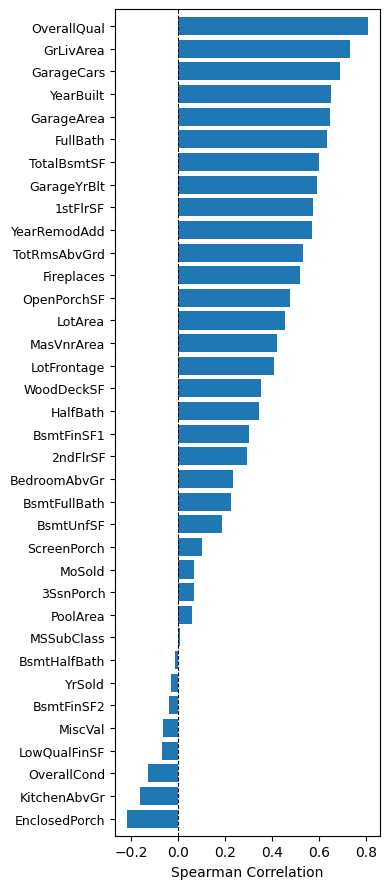

In [58]:
# to get a first estimate of which features are important we can just
# look at which of the numeric features correlate with sale price.
# note: use spearman correlation to catch any monotonic relationships
#       that might be nonlinear
correlations = house_data.corr(numeric_only=True, method='spearman')['SalePrice'].sort_values().drop(['SalePrice', 'Id'])

fig, ax = plt.subplots(figsize=(4,9))

ax.barh(correlations.index, correlations.values)
ax.axvline(0, color='k', linewidth=0.75, linestyle='--')
ax.tick_params(axis='y', labelsize=9)
ax.set_xlabel('Spearman Correlation')
ax.margins(y=0.01)

fig.tight_layout()
plt.show()

We have a lot of data columns to look at. Let's start by considering those that have the largest correlation with sale price and identifying any correlations between columns so we can reduce redundancy

In [69]:
# GrLivArea is just the sum of the 3 other internal square footage columns
sum(house_data[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']].sum(axis=1) - house_data['GrLivArea']) == 0

True

In [ ]:
# YearRemodAdd and GarageYrBlt have a lot of data points that are just YearBuilt.
# if we remove the 
house_data['YearRemodAdd_delta'] = house_data['YearRemodAdd'] - house_data['YearBuilt']
house_data['GarageYrBlt_delta']  = house_data['GarageYrBlt'] - house_data['YearBuilt']

print('Spearman Correlation after YearBuilt subtracted:')
house_data[['YearRemodAdd_delta', 'GarageYrBlt_delta', 'SalePrice']].corr(method='spearman')['SalePrice'].drop('SalePrice')

Spearman Correlation after YearBuilt subtracted:


YearRemodAdd_delta   -0.199935
GarageYrBlt_delta    -0.287761
Name: SalePrice, dtype: float64

In [ ]:
# we can combine all the bathroom columns into one combined total bathrooms number
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

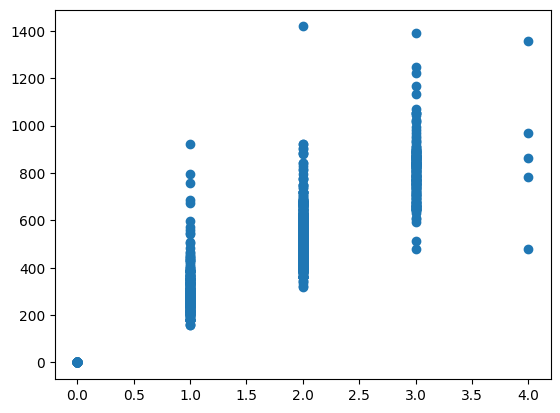

In [65]:
plt.scatter(house_data['GarageCars'], house_data['GarageArea'])
plt.show()

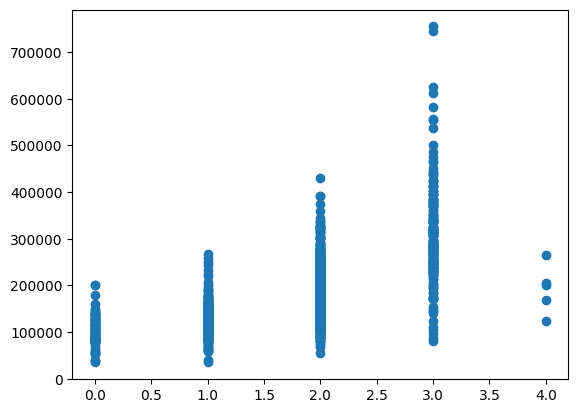

In [72]:
plt.scatter(house_data['GarageCars'], house_data['SalePrice'])
plt.show()

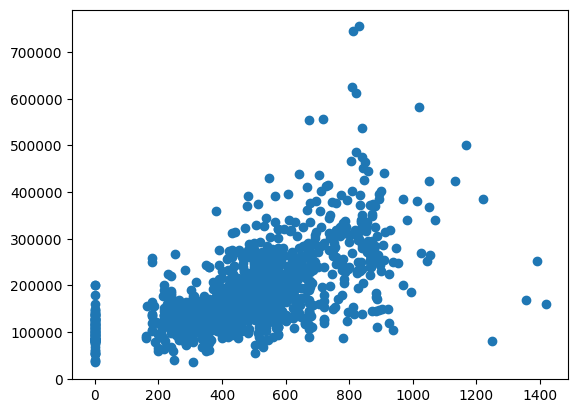

In [73]:
plt.scatter(house_data['GarageArea'], house_data['SalePrice'])
plt.show()

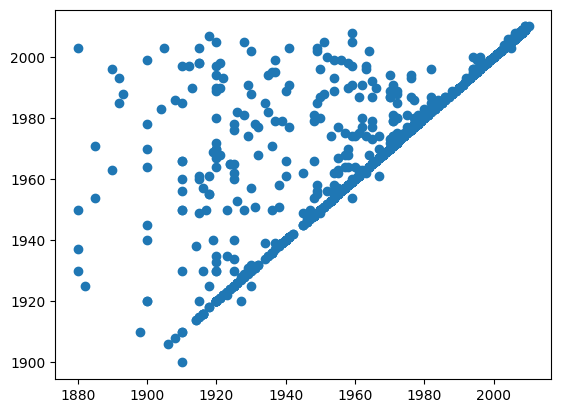

In [62]:
plt.scatter(house_data['YearBuilt'], house_data['GarageYrBlt'])
plt.show()

In [76]:
house_data['GarageYrBlt'].isna().sum()

np.int64(81)

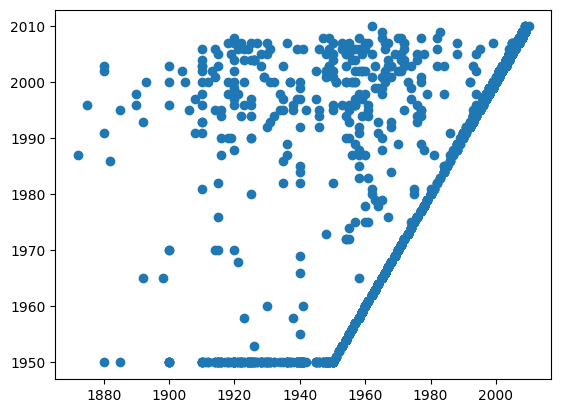

In [71]:
plt.scatter(house_data['YearBuilt'], house_data['YearRemodAdd'])
plt.show()

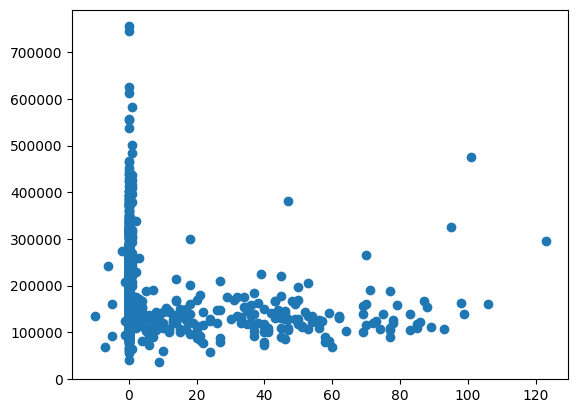

In [ ]:
plt.scatter(house_data['GarageYrBlt'] - house_data['YearBuilt'], house_data['SalePrice'])
plt.show()

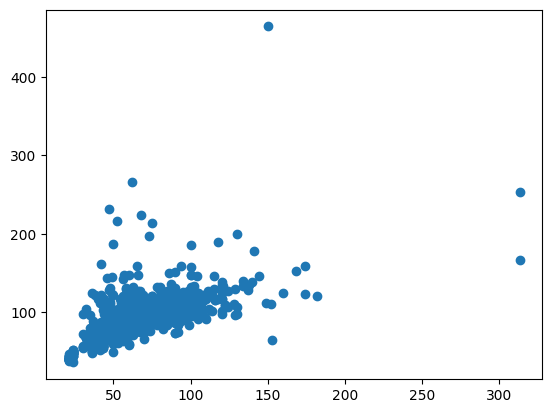

In [13]:
plt.scatter(house_data['LotFrontage'], np.sqrt(house_data['LotArea']))
plt.show()

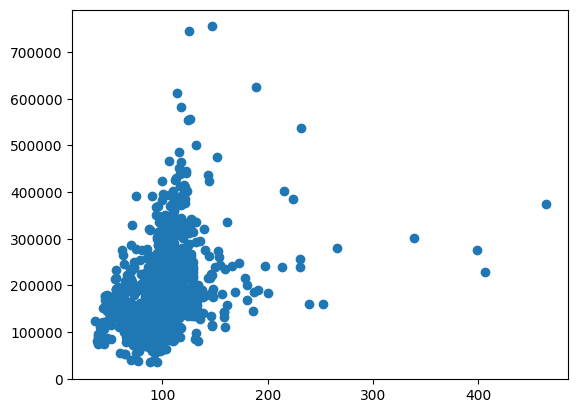

In [16]:
plt.scatter(np.sqrt(house_data['LotArea']), house_data['SalePrice'])
plt.show()

In [136]:
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

# build some useful features

# combine all bathroom columns to get a total bathroom count 
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

# format sale year and month into one continuous sale date
house_data['DateSold'] = house_data['YrSold'] + (house_data['MoSold'] - 1) / 12.

In [ ]:
house_data.corr(numeric_only=True)['SalePrice'].sort_values(

In [137]:
house_data[['DateSold', 'MoSold', 'SalePrice']].corr()[['SalePrice']]

,SalePrice
DateSold,-0.021267
MoSold,0.046432
SalePrice,1.000000


In [60]:
house_data[house_data['PoolArea'] > 0]['PoolArea'].count() / house_data['PoolArea'].count()

np.float64(0.004794520547945206)

In [70]:
house_data['OverallCond'].corr(house_data['OverallQual'], method='pearson')

np.float64(-0.09193234263907181)

In [ ]:
# final model features
features = ['LotArea',   # lot area
            'YearBuilt', # year built
            'DateSold',  # sold date, combined year and month
            'TotBath',   # total number of bathrooms
            'MiscVal',   # Miscellaneous value should probably direclty impact the sale price but only in ~50 (3%) of training data so might overfit?
            ]

In [78]:
house_data[house_data['LowQualFinSF'] > 0]['LowQualFinSF'].count()

np.int64(26)

In [ ]:
house_data['NumFlr'] = (house_data['2ndFlrSF'] > 0).astype(int) + 1
house_data['TotSF']  = house_data[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']].sum(axis=1) # this is just GrLivArea

In [111]:
house_data[['KitchenAbvGr', 'BedroomAbvGr', 'TotBath', 'TotRmsAbvGrd']]

,KitchenAbvGr,BedroomAbvGr,TotBath,TotRmsAbvGrd
0,1,3,3.5,8
1,1,3,2.5,6
2,1,3,3.5,6
3,1,3,2.0,7
4,1,4,3.5,9
...,...,...,...,...
1455,1,3,2.5,7
1456,1,3,3.0,7
1457,1,4,2.0,9
1458,1,2,2.0,5


<Axes: >

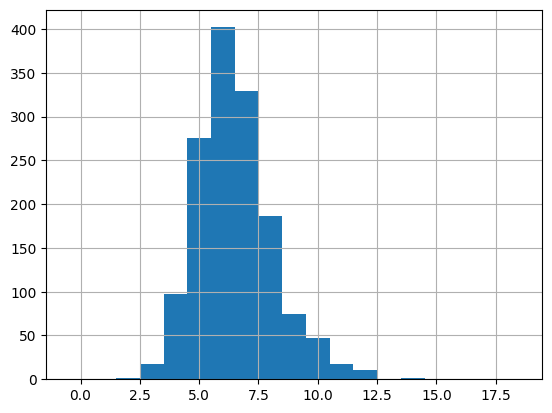

In [123]:
house_data['TotRmsAbvGrd'].hist(bins=np.arange(20) - 0.5)

In [102]:
house_data[house_data['GrLivArea'] > house_data['1stFlrSF'] + house_data['2ndFlrSF']][['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']]

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
51,816,0,360,1176
88,1013,0,513,1526
125,520,0,234,754
170,854,0,528,1382
185,1518,1518,572,3608
187,808,704,144,1656
197,1360,1360,392,3112
198,929,929,371,2229
263,926,0,390,1316
267,1052,720,420,2192


In [106]:
# features to use in model
features = ['LotArea', 'YearBuilt', 'YrSold', 'NumFlr', 'TotSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']
# features = ['LotArea', 'YearBuilt', 'YrSold', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']

# split training data into training and validation
X = house_data[features]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1234)

In [107]:
# test approach 1, use a random forest regressor
rf_model = RandomForestRegressor(random_state=1234)
rf_model.fit(train_X, train_y)
rf_val_predictions = rf_model.predict(val_X)
rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

print(f'Validation MAE for Random Forest Model: ${rf_val_mae:,.0f}')

Validation MAE for Random Forest Model: $21,625


In [108]:
print('Feature Importances')
for i in range(len(features)):
    print(f'{rf_model.feature_names_in_[i]:<15} : {rf_model.feature_importances_[i]:.3f}')

Feature Importances
LotArea         : 0.080
YearBuilt       : 0.319
YrSold          : 0.012
NumFlr          : 0.039
TotSF           : 0.464
FullBath        : 0.015
BedroomAbvGr    : 0.014
TotRmsAbvGrd    : 0.029
TotBath         : 0.027
LowQualFinSF    : 0.002


### Train model on full dataset and generate final predictions

In [ ]:
# To improve accuracy, create a new Random Forest model which you will train on all training data
rf_model_on_full_data = RandomForestRegressor(random_state=1234)

# fit rf_model_on_full_data on all data from the training data
rf_model_on_full_data.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
path_test_data = './input/test.csv.gz'
test_data      = pd.read_csv(path_test_data)

test_X     = test_data[features]
test_preds = rf_model.predict(test_X)

In [29]:
# save final predictions
output = pd.DataFrame({'Id'        : test_data.Id,
                       'SalePrice' : test_preds,
                       })
output.to_csv('./output/submission.csv', index=False)